In [ ]:
# 02_model_socal.ipynb — CELL 1: SETUP (load everything)

import pandas as pd
import numpy as np
from pathlib import Path

# ---- paths (you already confirmed these exist) ----
kelp_path = Path("../../1_DATA/processed/kelp_timeseries_socalv1_bbox_quarterly.csv")
sst_feat_path = Path("../../1_DATA/processed/oisst_features_quarterly.csv")

# ---- load kelp ----
df_kelp = pd.read_csv(kelp_path, index_col=0, parse_dates=True).sort_index()

# coverage==0 means missing imagery, not real zero kelp
df_kelp.loc[df_kelp["coverage"] == 0, "kelp_area"] = np.nan

# smooth AFTER fixing missing (4 quarters ≈ 1 year)
df_kelp["kelp_smooth"] = df_kelp["kelp_area"].rolling(4, center=True, min_periods=1).mean()

# ---- load SST features (already aligned to kelp timestamps) ----
df_sst = pd.read_csv(sst_feat_path, index_col=0, parse_dates=True).sort_index()

print("Kelp rows:", len(df_kelp), "| range:", df_kelp.index.min(), "to", df_kelp.index.max())
print("SST  rows:", len(df_sst),  "| range:", df_sst.index.min(),  "to", df_sst.index.max())
print("Kelp cols:", list(df_kelp.columns))
print("SST  cols:", list(df_sst.columns))

df_kelp.head()

Kelp rows: 167 | range: 1984-02-15 00:00:00 to 2025-08-15 00:00:00
SST  rows: 167 | range: 1984-02-15 00:00:00 to 2025-08-15 00:00:00
Kelp cols: ['kelp_area', 'coverage', 'kelp_smooth', 'coverage_frac']
SST  cols: ['sst_q_mean', 'sstanom_q_mean', 'sstanom_q_max', 'sstanom_q_mean_lag1']


,kelp_area,coverage,kelp_smooth,coverage_frac
1984-02-15,NaN,0,9.290381e+06,0.000000
1984-05-15,9290381.0,112026,9.290381e+06,0.975547
1984-08-15,NaN,0,6.370366e+06,0.000000
1984-11-15,3450350.0,114799,6.685867e+06,0.999695
1985-02-15,7316869.0,114812,8.600573e+06,0.999808


In [4]:
# 02_model_socal.ipynb — CELL 2: CLEAN + MERGE (make the analysis table)

# merge
df = df_kelp.join(df_sst, how="inner").sort_index()

# coverage quality filter (removes sketchy kelp quarters)
cov_thresh = 0.8 * df["coverage"].max()
df = df[df["coverage"] >= cov_thresh].copy()

# drop rows missing key predictors (will drop 2021 SST gap automatically)
need = ["kelp_smooth", "sstanom_q_mean", "sstanom_q_max"]
for c in need:
    if c not in df.columns:
        raise KeyError(f"Missing column '{c}' in merged table. Available: {list(df.columns)}")

df = df.dropna(subset=need)

print("Merged+clean rows:", len(df))
print("Range:", df.index.min(), "to", df.index.max())
print("Coverage threshold:", cov_thresh)

df.head()

Merged+clean rows: 157
Range: 1984-05-15 00:00:00 to 2025-08-15 00:00:00
Coverage threshold: 91867.20000000001


,kelp_area,coverage,kelp_smooth,coverage_frac,sst_q_mean,sstanom_q_mean,sstanom_q_max,sstanom_q_mean_lag1
1984-05-15,9290381.0,112026,9.290381e+06,0.975547,14.784969,0.499183,0.839190,1.022278
1984-11-15,3450350.0,114799,6.685867e+06,0.999695,15.633710,-0.445956,-0.300495,2.072631
1985-02-15,7316869.0,114812,8.600573e+06,0.999808,13.353732,-0.529773,-0.279811,-0.445956
1985-08-15,3561541.0,113278,6.637612e+06,0.986450,17.502159,0.047131,0.271622,-0.360834
1985-11-15,637540.0,112500,5.228020e+06,0.979675,15.583540,-0.496127,-0.152170,0.047131


count    167.000000
mean      -0.029801
std        1.296639
min       -1.740225
25%       -0.955732
50%       -0.461626
75%        0.677661
max        3.884071
Name: kelp_q_z, dtype: float64


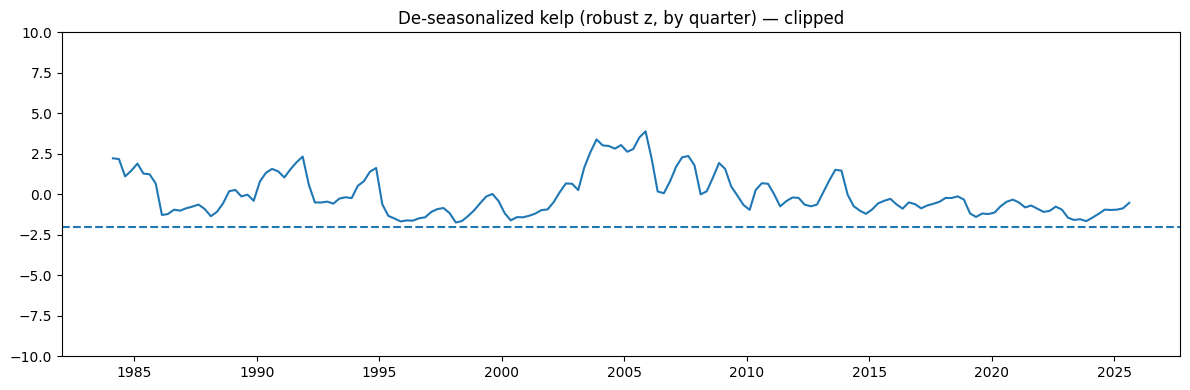

,start,end,n_q,min_z,duration_years
kelp_q_z,,,,,


In [12]:
### defining collapse using z
import numpy as np
import matplotlib.pyplot as plt

# use your CLEANED modeling table (after coverage filter + dropna)
df["q"] = df.index.quarter

baseline = df.loc["1984":"2013"]  # pre-Blob baseline, but only clean rows

med = baseline.groupby("q")["kelp_smooth"].median()
mad = baseline.groupby("q")["kelp_smooth"].apply(lambda x: np.median(np.abs(x - np.median(x))) + 1e-9)

df["kelp_q_z"] = (df["kelp_smooth"] - df["q"].map(med)) / df["q"].map(mad)

print(df["kelp_q_z"].describe())

# plot (clip so outliers don't flatten everything)
plt.figure(figsize=(12,4))
plt.plot(df.index, df["kelp_q_z"].clip(-10,10))
plt.axhline(-2, linestyle="--")
plt.ylim(-10, 10)
plt.title("De-seasonalized kelp (robust z, by quarter) — clipped")
plt.tight_layout()
plt.show()

# "doesn't rebound" = sustained low z episodes
low = df["kelp_q_z"] <= -2
seg = (low != low.shift()).cumsum()

episodes = (df[low].groupby(seg)["kelp_q_z"]
            .agg(start=lambda s: s.index.min(),
                 end=lambda s: s.index.max(),
                 n_q="size",
                 min_z="min"))
episodes["duration_years"] = episodes["n_q"] / 4

display(episodes.sort_values("duration_years", ascending=False).head(10))

threshold: -1.3476642280181552
counts: collapse
0    149
1     18
Name: count, dtype: int64


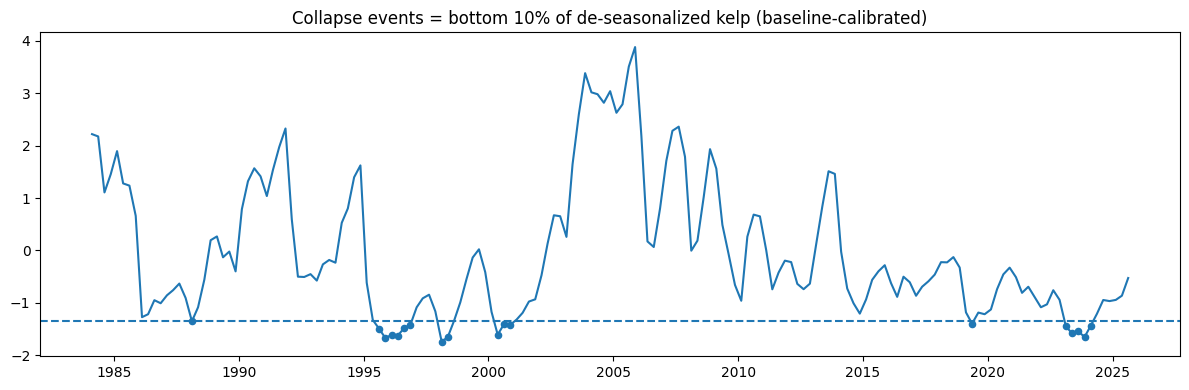

In [13]:
# collapse = unusually low for that quarter (quantile-based, baseline-calibrated)

base = df.loc["1984":"2013", "kelp_q_z"]
thresh = base.quantile(0.10)   # try 0.10 first; later test 0.05

df["collapse"] = (df["kelp_q_z"] <= thresh).astype(int)

print("threshold:", thresh)
print("counts:", df["collapse"].value_counts())

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(df.index, df["kelp_q_z"])
plt.axhline(thresh, linestyle="--")
plt.scatter(df.index[df["collapse"]==1],
            df.loc[df["collapse"]==1, "kelp_q_z"], s=20)
plt.title("Collapse events = bottom 10% of de-seasonalized kelp (baseline-calibrated)")
plt.tight_layout()
plt.show()

In [14]:
# collapse episodes (runs of consecutive collapse quarters)
low = df["collapse"] == 1
seg = (low != low.shift()).cumsum()

episodes = (df[low].groupby(seg)["kelp_q_z"]
            .agg(start=lambda s: s.index.min(),
                 end=lambda s: s.index.max(),
                 n_q="size",
                 min_z="min"))
episodes["duration_years"] = episodes["n_q"] / 4

display(episodes.sort_values("duration_years", ascending=False).head(15))

,start,end,n_q,min_z,duration_years
collapse,,,,,
4,1995-08-15,1996-11-15,6,-1.673651,1.50
12,2023-02-15,2024-02-15,5,-1.656677,1.25
8,2000-05-15,2000-11-15,3,-1.608013,0.75
6,1998-02-15,1998-05-15,2,-1.740225,0.50
2,1988-02-15,1988-02-15,1,-1.353815,0.25
10,2019-05-15,2019-05-15,1,-1.397666,0.25


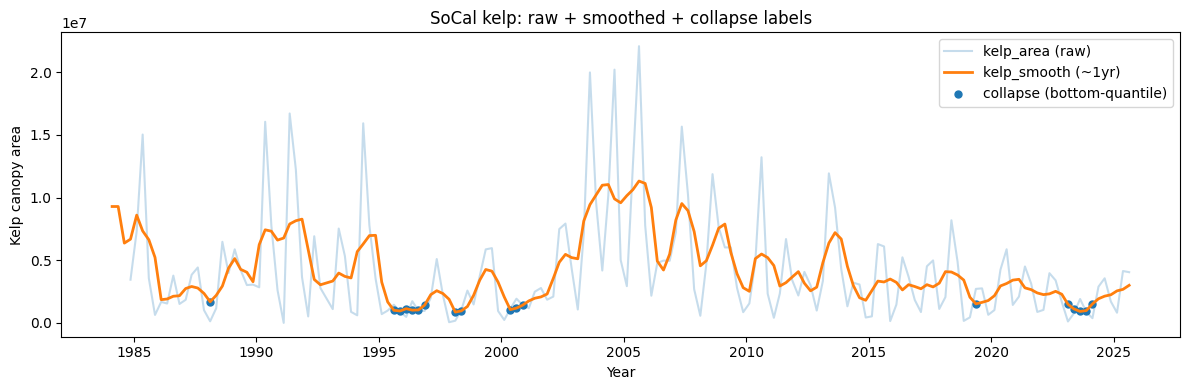

In [ ]:
# plot the low thresh holds
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df.index, df["kelp_area"], alpha=0.25, label="kelp_area (raw)")
plt.plot(df.index, df["kelp_smooth"], linewidth=2, label="kelp_smooth (~1yr)")

if "collapse" in df.columns:
    plt.scatter(df.index[df["collapse"]==1],
                df.loc[df["collapse"]==1, "kelp_smooth"],
                s=25, label="collapse (bottom-quantile)")

plt.title("SoCal kelp: raw + smoothed + collapse labels")
plt.xlabel("Year")
plt.ylabel("Kelp canopy area")
plt.legend()
plt.tight_layout()
plt.show()

Suppression params: {'SUP_ROLL': 4, 'SUP_QTAIL': 0.1, 'sup_thresh': -1.2476630952008605}
Suppressed counts: {0: 150, 1: 17}


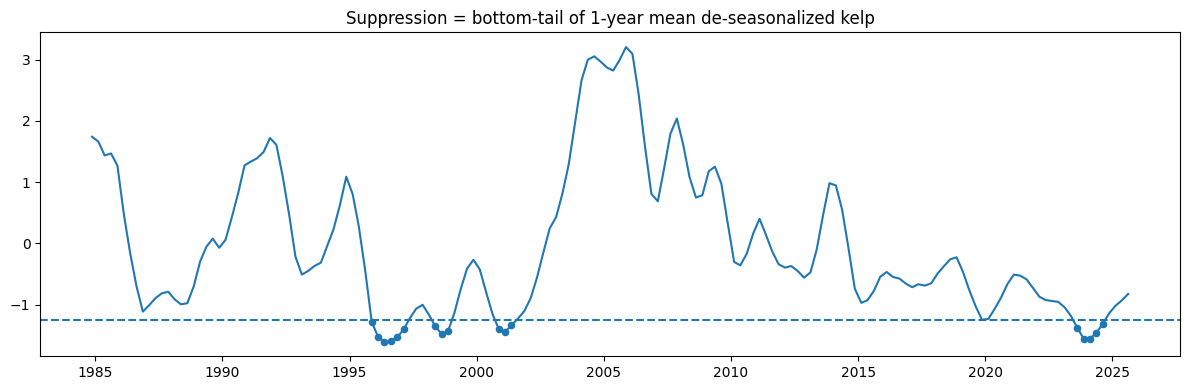

In [18]:
# === SUPPRESSION LABEL (persistent low state) ===
# idea: kelp is "suppressed" if the *1-year mean* of de-seasonalized kelp is in the bottom tail

SUP_ROLL = 4      # 4 quarters = 1 year
SUP_QTAIL = 0.10  # tune later (0.05 / 0.10 / 0.15)
BASE_START, BASE_END = "1984", "2013"

# 1-year rolling mean of kelp_q_z
df["kelp_z_1yr"] = df["kelp_q_z"].rolling(SUP_ROLL, min_periods=SUP_ROLL).mean()

# threshold learned from baseline distribution of the 1-year metric
base_1yr = df.loc[BASE_START:BASE_END, "kelp_z_1yr"].dropna()
sup_thresh = base_1yr.quantile(SUP_QTAIL)

df["suppressed"] = (df["kelp_z_1yr"] <= sup_thresh).astype(int)

print("Suppression params:", {"SUP_ROLL": SUP_ROLL, "SUP_QTAIL": SUP_QTAIL, "sup_thresh": float(sup_thresh)})
print("Suppressed counts:", df["suppressed"].value_counts().to_dict())

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(df.index, df["kelp_z_1yr"])
plt.axhline(sup_thresh, linestyle="--")
plt.scatter(df.index[df["suppressed"]==1],
            df.loc[df["suppressed"]==1, "kelp_z_1yr"], s=20)
plt.title("Suppression = bottom-tail of 1-year mean de-seasonalized kelp")
plt.tight_layout()
plt.show()